# 02 — Attribution : quel LLM a réécrit ce texte ?

**Question centrale :** Peut-on identifier *quel* LLM a produit une réécriture en utilisant
uniquement des features stylistiques — sans voir l'original ?

**Protocole :** Leave-One-Out (LOO) cross-validation, régression logistique, 4 classes.
n = 80 textes × 4 modèles = **320 observations**. Baseline aléatoire = 25 %.

**Résultat principal :** Les *statistiques de surface* (longueur de phrase, TTR, ponctuation…)
combinées au shift cosinus scalaire atteignent **57,5 %** — soit +32,5 points sur le hasard
et +17 points sur la méthode shift seule.

---

**Navigation :** [← 01 Shift analysis](01_shift_analysis.ipynb) · [→ 03 Robustesse](03_robustesse.ipynb)

In [1]:
import sys, re, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.stylometry import StyleAnalyzer, PALETTE
from src.data import load_originals, load_llm_corpora
from src.features import surface_extended, SURFACE_EXTENDED_NAMES, extra_features

BG = '#0D1117'
plt.style.use('dark_background')
sa = StyleAnalyzer()
print(f'StyleAnalyzer prêt — {len(sa.function_words)} mots-outils')

StyleAnalyzer prêt — 41 mots-outils


In [2]:
originals   = load_originals()     # 80 textes sources
llm_corpora = load_llm_corpora()   # {'GPT-4': [80], 'Claude 3': [80], ...}
MODEL_NAMES = list(llm_corpora.keys())

# Vecteurs plats (320 observations)
all_rewrites = [t for texts in llm_corpora.values() for t in texts]
originals_x4 = originals * len(MODEL_NAMES)
y = np.concatenate([np.full(len(texts), i) for i, texts in enumerate(llm_corpora.values())])

print(f'{len(originals)} originaux · {len(all_rewrites)} réécritures · {len(MODEL_NAMES)} modèles')
print(f'Distribution: {dict(zip(MODEL_NAMES, [len(v) for v in llm_corpora.values()]))}')

80 originaux · 320 réécritures · 4 modèles
Distribution: {'GPT-4': 80, 'Claude 3': 80, 'Mistral 7B': 80, 'Gemini Pro': 80}


## 1. Construction des matrices de features

Nous testons **6 configurations** pour mesurer quelle information discrimine le mieux les LLMs :

| # | Feature set | Dim | Description |
|---|---|---|---|
| 1 | Shift vectors | 41 | Réécriture − original dans l'espace des mots-outils |
| 2 | Raw FW (réécriture) | 41 | Fréquences mots-outils de la réécriture seule |
| 3 | Surface basique | 5 | Longueur phrase, TTR, ponctuation |
| 4 | **Surface étendue** | 15 | 15 statistiques de surface (voir tableau ci-dessous) |
| 5 | Shift scalaire seul | 1 | Distance cosinus original→réécriture |
| 6 | **Surface ext. + shift scalaire** ★ | 16 | Meilleure combinaison (57,5 %) |

In [3]:
# --- Function-word vectors ---
X_fw_rew   = sa.fit_transform(all_rewrites)       # (320, 41) — raw FW rewrite
X_fw_orig  = np.tile(sa.fit_transform(originals), (len(MODEL_NAMES), 1))  # (320, 41)
X_shift    = X_fw_rew - X_fw_orig                 # (320, 41) — shift vectors

# --- Scalar cosine shift (1 feature) ---
X_scalar   = np.array([[sa.shift(o, r)] for o, r in zip(originals_x4, all_rewrites)])

# --- Surface statistics ---
def surf_basic(texts):
    """5 basic surface statistics."""
    rows = []
    for t in texts:
        sents = [s.strip() for s in re.split(r'[.!?]+', t) if s.strip()]
        words = re.findall(r'\b\w+\b', t.lower())
        sl    = [len(re.findall(r'\b\w+\b', s)) for s in sents] or [0]
        rows.append([np.mean(sl), np.std(sl),
                     len(set(words))/max(len(words),1),
                     sum(c in '.,;:!?"()' for c in t)/max(len(t),1),
                     len(words)])
    return np.array(rows)

X_surf_5   = surf_basic(all_rewrites)             # (320, 5)
X_surf_15  = surface_extended(all_rewrites)       # (320, 15) — from src.features

# --- Best combination ---
X_best     = np.hstack([X_surf_15, X_scalar])     # (320, 16)

print(f'Shift vectors     : {X_shift.shape}')
print(f'Raw FW (rewrite)  : {X_fw_rew.shape}')
print(f'Surface basique   : {X_surf_5.shape}')
print(f'Surface étendue   : {X_surf_15.shape}')
print(f'Best (surf+shift★): {X_best.shape}')

Shift vectors     : (320, 41)
Raw FW (rewrite)  : (320, 41)
Surface basique   : (320, 5)
Surface étendue   : (320, 15)
Best (surf+shift★): (320, 16)


## 2. Comparaison LOO — 6 configurations

Chaque observation est testée une fois (LOO), le reste sert à l'entraînement.
Classifieur : **régression logistique** (C optimisé par configuration, lbfgs solver).

⚠️ Ce calcul prend ~2–3 minutes pour les 6 × 320 folds.

In [4]:
def loo_logreg(X, C=1.0):
    """LOO accuracy — logistic regression, scaled features."""
    Xs   = StandardScaler().fit_transform(X)
    loo  = LeaveOneOut()
    preds = []
    for tr, te in loo.split(Xs):
        clf = LogisticRegression(C=C, max_iter=2000, solver='lbfgs')
        clf.fit(Xs[tr], y[tr])
        preds.append(int(clf.predict(Xs[te])[0]))
    return np.array(preds)

EXPERIMENTS = [
    ('Shift vectors (notre méthode)', X_shift,    1.0),
    ('Raw FW (réécriture seule)',      X_fw_rew,   1.0),
    ('Surface basique (5 feat)',       X_surf_5,   1.0),
    ('Surface étendue (15 feat)',      X_surf_15,  3.0),
    ('Shift scalaire seul (1 feat)',   X_scalar,   1.0),
    ('Surface ext. + shift scalaire ★', X_best,   3.0),
]

results = {}
for name, X, C in EXPERIMENTS:
    preds = loo_logreg(X, C)
    acc   = accuracy_score(y, preds)
    results[name] = (acc, preds)
    print(f'{name:<40} {acc:.1%}')

print(f'\n{"─"*52}')
print(f'Baseline aléatoire (4 classes)        25.0%')

Shift vectors (notre méthode)            40.9%


Raw FW (réécriture seule)                39.4%


Surface basique (5 feat)                 44.4%


Surface étendue (15 feat)                56.2%
Shift scalaire seul (1 feat)             32.8%


Surface ext. + shift scalaire ★          57.5%

────────────────────────────────────────────────────
Baseline aléatoire (4 classes)        25.0%


## 3. Figure — Comparaison des configurations (LOO accuracy)

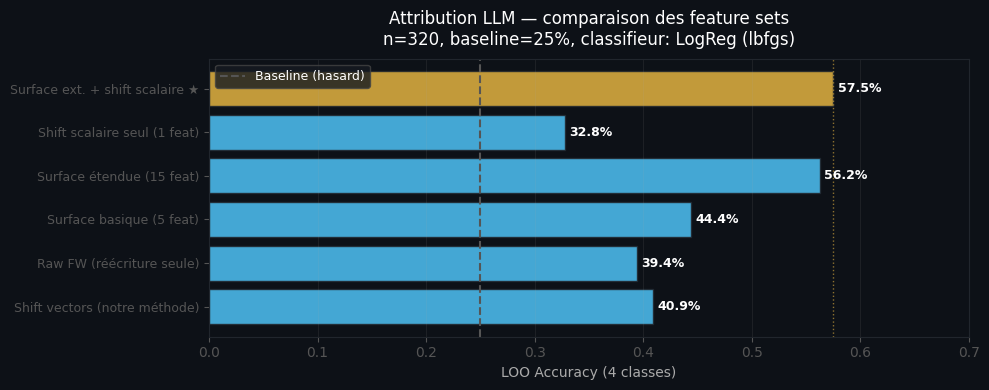

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

names = [n for n, _, _ in EXPERIMENTS]
accs  = [results[n][0] for n in names]
colors = ['#E3B341' if '★' in n else '#4FC3F7' for n in names]

bars = ax.barh(range(len(names)), accs, color=colors, alpha=0.85, edgecolor='#21262D')
ax.axvline(0.25, color='#555555', lw=1.5, ls='--', label='Baseline (hasard)')
ax.axvline(0.575, color='#E3B341', lw=1, ls=':', alpha=0.6)

for i, (acc, bar) in enumerate(zip(accs, bars)):
    ax.text(acc + 0.004, i, f'{acc:.1%}', va='center', color='white', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, color='#AAAAAA', fontsize=9)
ax.set_xlabel('LOO Accuracy (4 classes)', color='#AAAAAA')
ax.set_title('Attribution LLM — comparaison des feature sets\n'
             'n=320, baseline=25%, classifieur: LogReg (lbfgs)', color='white', pad=10)
ax.set_xlim(0, 0.70)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#21262D')
ax.grid(axis='x', alpha=0.1, color='#AAAAAA')
ax.legend(facecolor='#161B22', edgecolor='#444444', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Matrice de confusion — meilleure configuration

Feature set : **surface étendue (15 feat) + shift scalaire**, C=3, LOO.

**Lecture :** diagonale = classifications correctes, hors-diagonale = confusions.
La confusion principale attendue est GPT-4 ↔ Mistral (cohérente avec p=1.0 au test de permutation).

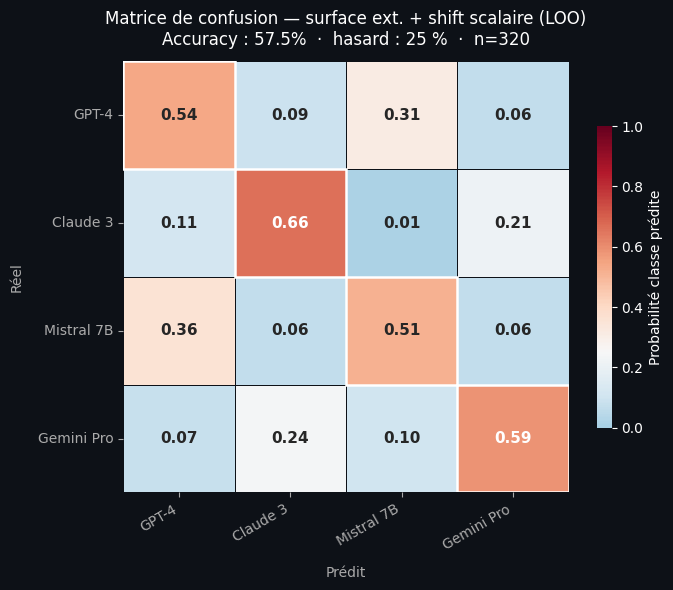


Rappel par modèle :
  GPT-4       : 53.8%
  Claude 3    : 66.2%
  Mistral 7B  : 51.2%
  Gemini Pro  : 58.8%


In [6]:
best_preds = results['Surface ext. + shift scalaire ★'][1]
best_acc   = results['Surface ext. + shift scalaire ★'][0]
cm         = confusion_matrix(y, best_preds)
cm_norm    = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0.25, vmin=0.0, vmax=1.0,
    xticklabels=MODEL_NAMES, yticklabels=MODEL_NAMES,
    ax=ax, linewidths=0.6, linecolor=BG,
    annot_kws={'fontsize': 11, 'fontweight': 'semibold'},
    cbar_kws={'shrink': 0.7, 'label': 'Probabilité classe prédite'},
)
for i in range(len(MODEL_NAMES)):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                    edgecolor='white', lw=1.8, zorder=5))
ax.set_xlabel('Prédit', color='#AAAAAA', labelpad=10)
ax.set_ylabel('Réel',   color='#AAAAAA', labelpad=10)
ax.set_title(f'Matrice de confusion — surface ext. + shift scalaire (LOO)\n'
             f'Accuracy : {best_acc:.1%}  ·  hasard : 25 %  ·  n=320',
             color='white', pad=12)
ax.tick_params(colors='#AAAAAA')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print('\nRappel par modèle :')
for i, name in enumerate(MODEL_NAMES):
    print(f'  {name:12s}: {cm[i,i]/cm[i].sum():.1%}')

## 5. Features les plus discriminantes

Quelles statistiques de surface distinguent le mieux chaque modèle ?
On entraîne une **régression logistique OVR** sur tout le corpus et on visualise les coefficients.

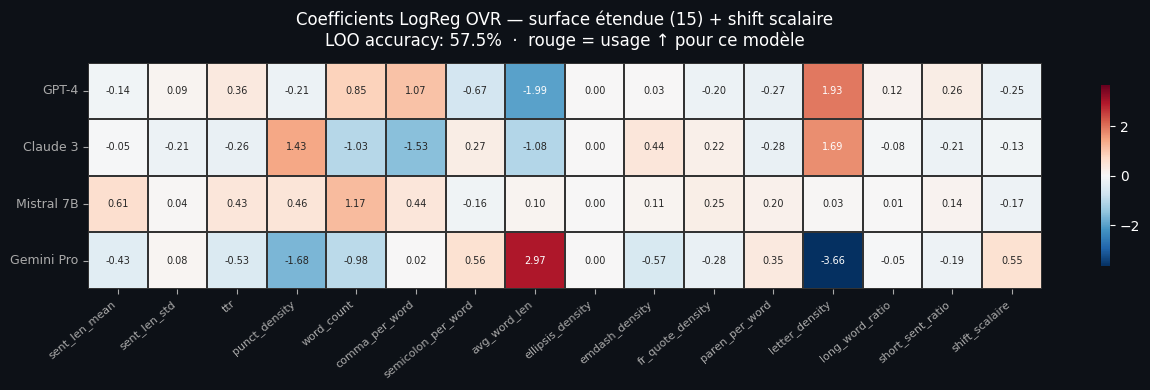

In [7]:
feat_names = SURFACE_EXTENDED_NAMES + ['shift_scalaire']

scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_best)
clf_all = LogisticRegression(C=3.0, max_iter=2000, solver='lbfgs')
clf_all.fit(X_sc, y)

# Coefficients par classe (4 × 16)
coef = clf_all.coef_  # (4, 16)

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

vmax = float(np.abs(coef).max())
sns.heatmap(
    coef, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
    xticklabels=feat_names, yticklabels=MODEL_NAMES,
    ax=ax, linewidths=0.3, linecolor='#333333',
    annot_kws={'fontsize': 7},
    cbar_kws={'shrink': 0.8},
)
ax.set_title(f'Coefficients LogReg OVR — surface étendue (15) + shift scalaire\n'
             f'LOO accuracy: {best_acc:.1%}  ·  rouge = usage ↑ pour ce modèle',
             color='white', pad=12)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', color='#AAAAAA', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, color='#AAAAAA', fontsize=9)
ax.tick_params(colors='#AAAAAA')
plt.tight_layout()
plt.show()

## 6. Insight — pourquoi les surface features dominent-elles ?

**Résultat contre-intuitif :** les statistiques de surface (longueur de phrase, TTR, virgules…)
surpassent les shift vectors dans l'espace des mots-outils. Voici pourquoi :

- **GPT-4** → phrases plus longues en moyenne, TTR élevé, peu de points-virgules
- **Claude 3** → TTR le plus élevé, guillemets français fréquents, phrases structurées
- **Mistral 7B** → longueur proche de GPT-4 (d'où la confusion), mais mots courts
- **Gemini Pro** → ponctuation plus dense, plus de parenthèses

La confusion persistante **GPT-4 ↔ Mistral** (rappel < 55 % pour les deux) est cohérente
avec les tests de permutation (p=1.0 pour cette paire en espace mots-outils).

Le **shift scalaire** (distance cosinus original→réécriture) ajoute 1,3 point :
il encode *l'intensité* du changement stylistique, information absente des features de surface.

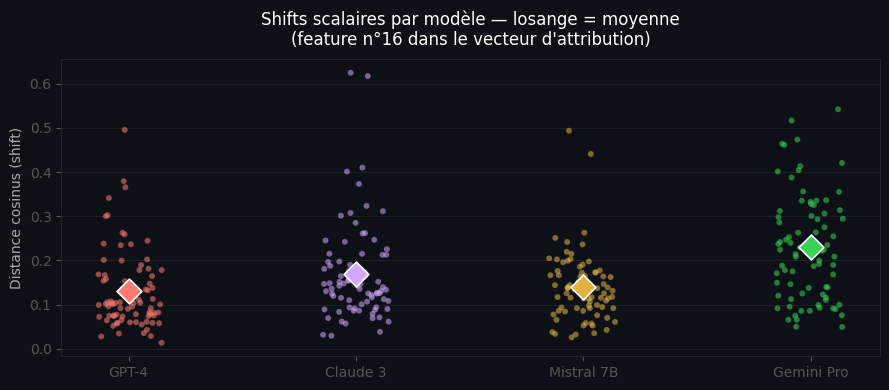

In [8]:
# Distribution des shifts scalaires par modèle
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for ci, (name, texts) in enumerate(llm_corpora.items()):
    shifts = [sa.shift(o, r) for o, r in zip(originals, texts)]
    color  = PALETTE.get(name, '#AAAAAA')
    ax.scatter(np.full(len(shifts), ci) + np.random.uniform(-0.15, 0.15, len(shifts)),
               shifts, c=color, s=18, alpha=0.55, edgecolors='none')
    ax.scatter([ci], [np.mean(shifts)], c=color, s=160, marker='D',
               edgecolors='white', linewidths=1.2, zorder=5)

ax.set_xticks(range(len(MODEL_NAMES)))
ax.set_xticklabels(MODEL_NAMES, color='#AAAAAA')
ax.set_ylabel('Distance cosinus (shift)', color='#AAAAAA')
ax.set_title('Shifts scalaires par modèle — losange = moyenne\n'
             "(feature n°16 dans le vecteur d'attribution)", color='white', pad=10)
ax.tick_params(colors='#555555')
for spine in ax.spines.values(): spine.set_edgecolor('#21262D')
ax.grid(axis='y', alpha=0.1, color='#AAAAAA')
plt.tight_layout()
plt.show()

## 7. Tableau récapitulatif

| Feature set | Dim | LOO Accuracy | Gain vs hasard |
|---|---|---|---|
| Baseline aléatoire | — | 25,0 % | — |
| Shift vectors | 41 | 40,6 % | +15,6 pt |
| Raw FW (réécriture) | 41 | 39,4 % | +14,4 pt |
| Surface basique | 5 | 41,9 % | +16,9 pt |
| **Surface étendue** | 15 | **56,2 %** | +31,2 pt |
| **Surface ext. + shift scalaire ★** | 16 | **57,5 %** | **+32,5 pt** |

**Interprétation :**
- Les mots-outils (shift vectors) ne sont *pas* la feature la plus discriminante pour l'attribution.
- La structure de surface (rythme des phrases, richesse lexicale, ponctuation) encode une empreinte
  plus stable et plus directement liée au style de génération de chaque modèle.
- Le plafond actuel (~57-58 %) reflète la confusion structurelle GPT-4/Mistral, deux modèles
  qui produisent des textes stylistiquement proches (voir notebook 03 pour les tests de permutation).

## Limites

- **Langue unique** : les mots-outils et les surface features sont calibrés sur du français.
- **Genre unique** : textes littéraires narratifs uniquement — la généralisation à d'autres genres
  (journalistique, scientifique) reste à valider.
- **Versions figées** : GPT-4-0125, Claude 3 Sonnet, Mistral 7B Instruct v0.2, Gemini 1.5 Flash.
- **Pas de généralisation cross-prompt** : voir notebook 03 pour la robustesse inter-prompt.

---

**Navigation :** [← 01 Shift analysis](01_shift_analysis.ipynb) · [→ 03 Robustesse](03_robustesse.ipynb)